# 3 · Analysis — vessels across the rainfall gradient

This notebook loads the tables that **notebook 2** wrote and asks the scientific
question: *does vessel anatomy change from wetter sites to drier ones?*

| Site    | Rainfall |
|---------|----------|
| `GUNDA` | high     |
| `NOCO`  | moderate |
| `STURT` | low      |

We look at vessel **size** (area), **roundness** (circularity), and
**elongation** (aspect ratio), then at how densely vessels pack the section
(area fraction). All numbers are in **pixel units** — see notebook 2 to switch on
micron calibration.

> Run `2_batch.ipynb` first: this notebook reads `outputs/all_vessels.csv` and
> `outputs/area_fraction.csv`.

In [1]:
import os
from pathlib import Path

if not Path("data/10x").exists() and Path("../data/10x").exists():
    os.chdir("..")
print("working directory:", Path.cwd())

working directory: C:\Users\metas\repos\vessel_analysis


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set_theme(style="whitegrid")

# Order categories along the gradient (wet -> dry) so every plot reads the same.
RAINFALL_ORDER = ["high", "moderate", "low"]
SITE_ORDER = ["GUNDA", "NOCO", "STURT"]

In [3]:
csv_path = Path("outputs/all_vessels.csv")
if not csv_path.exists():
    raise FileNotFoundError(
        "outputs/all_vessels.csv not found - run notebooks/2_batch.ipynb first."
    )

df = pd.read_csv(csv_path)
df["rainfall"] = pd.Categorical(df["rainfall"], categories=RAINFALL_ORDER, ordered=True)
print("loaded", len(df), "vessels from", df["source_image"].nunique(), "images")
df.head()

loaded 12090 vessels from 120 images


,source_image,vessel_id,circularity,area_px,area_um2,diam_major_px,diam_minor_px,feret_max_px,equiv_diam_px,aspect_ratio,eccentricity,solidity,touches_border,site,group,rainfall,cx,cy
0,GUNDA_ACC_T20_1_10x,1,0.716808,284.0,NaN,27.741283,13.539250,30.016662,19.015784,0.488054,0.872813,0.937294,False,GUNDA,ACC,high,767.109155,26.345070
1,GUNDA_ACC_T20_1_10x,2,0.665676,298.0,NaN,29.278972,14.476040,29.068884,19.478845,0.494418,0.869224,0.889552,False,GUNDA,ACC,high,743.785235,33.872483
2,GUNDA_ACC_T20_1_10x,3,0.347160,538.0,NaN,30.824108,26.657779,32.310989,26.172560,0.864835,0.502056,0.812689,False,GUNDA,ACC,high,51.485130,267.671004
3,GUNDA_ACC_T20_1_10x,4,0.253270,45.0,NaN,14.065579,6.552992,14.035669,7.569398,0.465889,0.884843,0.600000,False,GUNDA,ACC,high,137.000000,276.866667
4,GUNDA_ACC_T20_1_10x,5,0.863736,372.0,NaN,28.414401,16.888068,28.635642,21.763389,0.594349,0.804207,0.948980,False,GUNDA,ACC,high,121.338710,339.801075


## Keep the vessels we can trust

Two filters before any statistics:

- **Whole vessels only** (`~touches_border`). A vessel clipped by the image edge
  has an unreliable area and shape, so we drop it.
- **A sensible area window.** The package already removes specks and giant merged
  blobs; we tighten slightly to `50–3000 px` to focus on plausible single
  vessels. Adjust the bounds and re-run to see how sensitive the results are.

In [4]:
AREA_MIN, AREA_MAX = 50, 3000

whole = df[(~df["touches_border"])
           & (df["area_px"] >= AREA_MIN)
           & (df["area_px"] <= AREA_MAX)].copy()

# log area linearises the heavy right tail of vessel sizes
whole["log_area"] = np.log(whole["area_px"])

# guard: every site must be one we know how to order, else it would be silently
# dropped from the site-level summary / plots below.
assert set(whole["site"].unique()) <= set(SITE_ORDER), "unexpected site code in data"

print(f"{len(whole)} vessels kept ({len(whole)/len(df):.0%} of all detections)")
whole.groupby("rainfall", observed=True).size().rename("n_vessels")

10274 vessels kept (85% of all detections)


rainfall
high        1753
moderate    4012
low         4509
Name: n_vessels, dtype: int64

## Distributions by rainfall

Box plots of the three core metrics across the gradient. The box is the
interquartile range, the line is the median, and the whiskers reach the bulk of
the data.

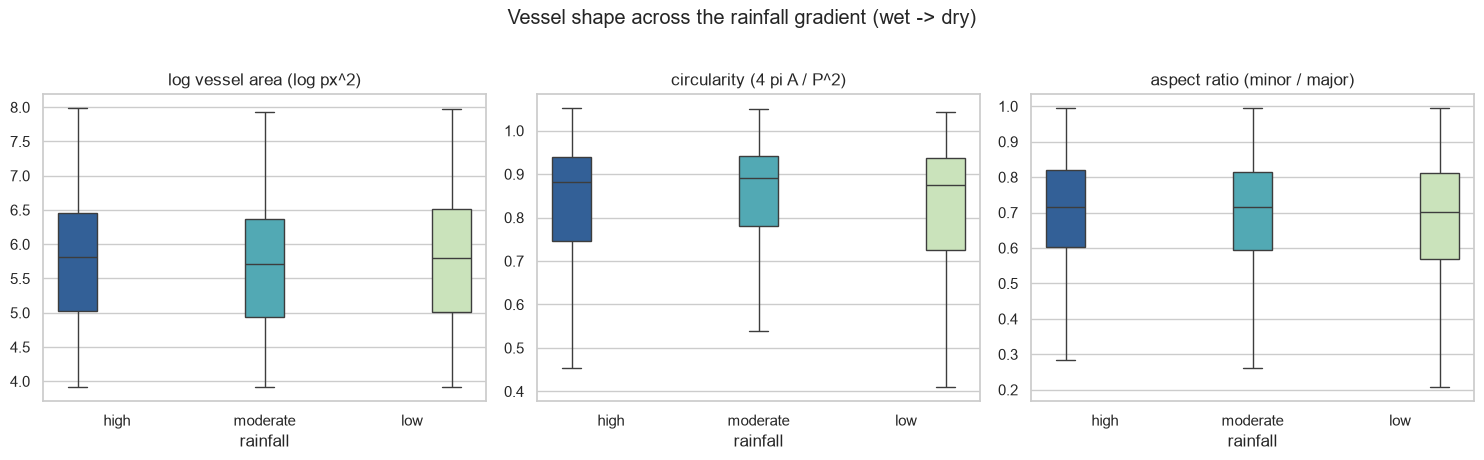

In [5]:
metrics = [("log_area", "log vessel area (log px^2)"),
           ("circularity", "circularity (4 pi A / P^2)"),
           ("aspect_ratio", "aspect ratio (minor / major)")]

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, (col, label) in zip(axes, metrics):
    sns.boxplot(data=whole, x="rainfall", y=col, order=RAINFALL_ORDER,
                hue="rainfall", hue_order=RAINFALL_ORDER, palette="YlGnBu_r",
                legend=False, showfliers=False, ax=ax)
    ax.set_title(label)
    ax.set_xlabel("rainfall")
    ax.set_ylabel("")
fig.suptitle("Vessel shape across the rainfall gradient (wet -> dry)", y=1.02)
plt.tight_layout()
plt.show()

The same metrics seen as smoothed distributions, which make shifts in the whole
shape (not just the median) easier to see.

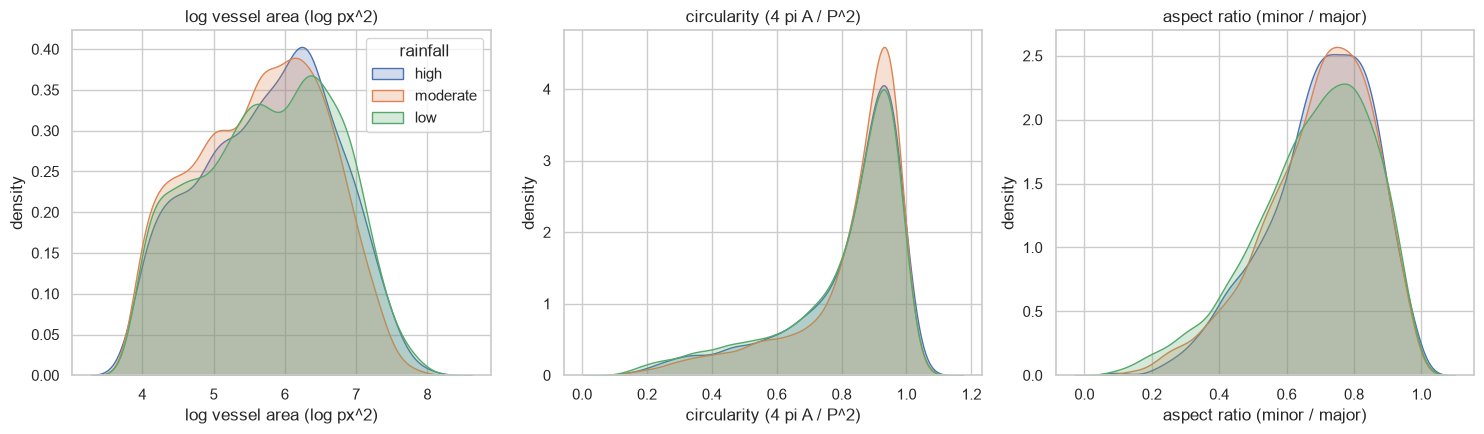

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, (col, label) in zip(axes, metrics):
    for rain in RAINFALL_ORDER:
        sns.kdeplot(whole.loc[whole["rainfall"] == rain, col],
                    label=rain, fill=True, alpha=0.25, ax=ax)
    ax.set_title(label)
    ax.set_xlabel(label)
    ax.set_ylabel("density")
axes[0].legend(title="rainfall")
plt.tight_layout()
plt.show()

## Median & IQR summary

A compact table: the median and interquartile range (IQR = 75th − 25th
percentile) of each metric, by rainfall class.

In [7]:
def iqr(x):
    return x.quantile(0.75) - x.quantile(0.25)

summary = (whole.groupby("rainfall", observed=True)[["area_px", "circularity", "aspect_ratio"]]
                .agg(["median", iqr])
                .round(3))
summary.insert(0, ("n_vessels", ""), whole.groupby("rainfall", observed=True).size())
summary

n_vessels area_px         circularity        aspect_ratio       
                    median     iqr      median    iqr       median    iqr
rainfall                                                                 
high          1753   337.0  479.00       0.881  0.194        0.716  0.215
moderate      4012   303.0  440.25       0.891  0.161        0.716  0.221
low           4509   331.0  530.00       0.874  0.211        0.703  0.242

In [8]:
# Same summary at the site level (site determines rainfall, but this keeps the
# individual sites visible).
site_summary = (whole.groupby("site")[["area_px", "circularity", "aspect_ratio"]]
                     .agg(["median", iqr])
                     .round(3)
                     .reindex(SITE_ORDER))
site_summary.insert(0, ("n_vessels", ""), whole.groupby("site").size().reindex(SITE_ORDER))
site_summary

n_vessels area_px         circularity        aspect_ratio       
                 median     iqr      median    iqr       median    iqr
site                                                                  
GUNDA      1753   337.0  479.00       0.881  0.194        0.716  0.215
NOCO       4012   303.0  440.25       0.891  0.161        0.716  0.221
STURT      4509   331.0  530.00       0.874  0.211        0.703  0.242

## How are the shape metrics related?

A correlation heatmap of the per-vessel metrics. Strong positive blocks among the
size metrics (area, diameters, Feret) are expected — they all measure "how big".
The shape metrics (circularity, aspect ratio, eccentricity, solidity) tell a
more independent story.

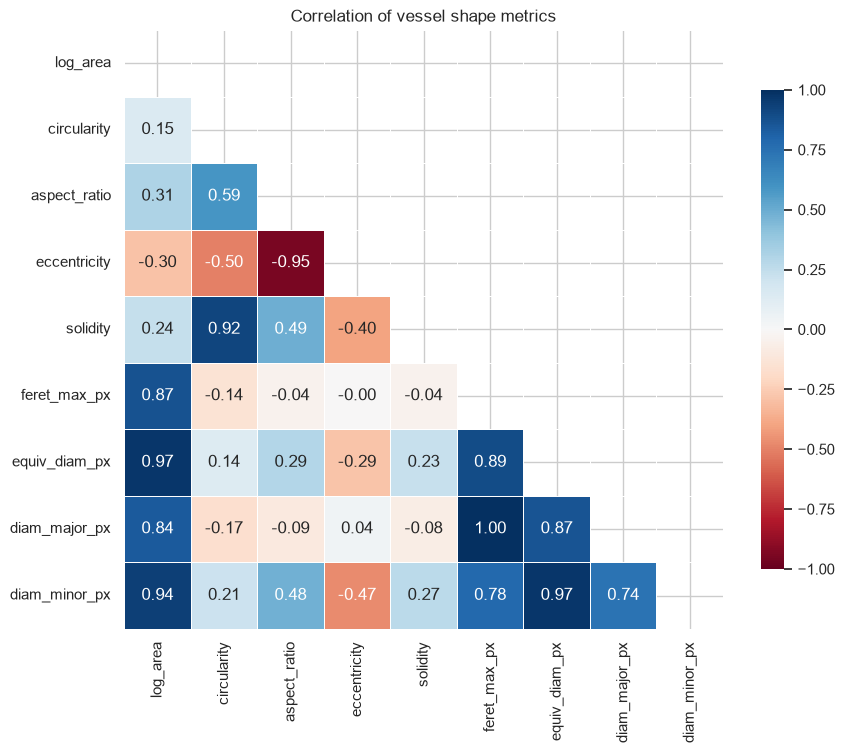

In [9]:
shape_cols = ["log_area", "circularity", "aspect_ratio", "eccentricity",
              "solidity", "feret_max_px", "equiv_diam_px",
              "diam_major_px", "diam_minor_px"]
corr = whole[shape_cols].corr()

mask = np.triu(np.ones_like(corr, dtype=bool))   # hide the redundant upper triangle
fig, ax = plt.subplots(figsize=(9, 7.5))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdBu",
            vmin=-1, vmax=1, square=True, linewidths=0.5,
            cbar_kws={"shrink": 0.8}, ax=ax)
ax.set_title("Correlation of vessel shape metrics")
plt.tight_layout()
plt.show()

### A ported view: circularity vs size, coloured by rainfall

The original `vessel_labelling` notebook plotted shape against size coloured by
rainfall. Here is the same idea on the corrected data — note the circularity axis
now sits up near 0.8–0.9 (Crofton perimeter), not down near 0.55.

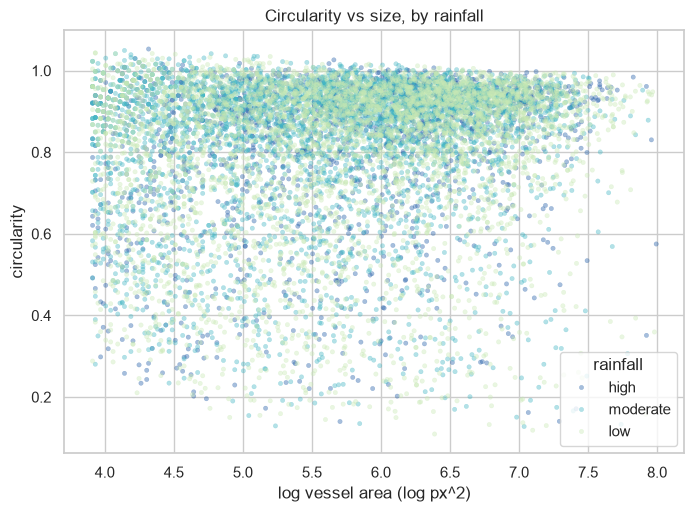

In [10]:
fig, ax = plt.subplots(figsize=(8, 5.5))
sns.scatterplot(data=whole, x="log_area", y="circularity", hue="rainfall",
                hue_order=RAINFALL_ORDER, palette="YlGnBu_r", s=10, alpha=0.4,
                edgecolor=None, ax=ax)
ax.set_xlabel("log vessel area (log px^2)")
ax.set_ylabel("circularity")
ax.set_title("Circularity vs size, by rainfall")
ax.legend(title="rainfall")
plt.show()

## Vessel packing: area fraction by site

Finally, how much of each section is vessel lumen? Each point is one image; we
group by site (ordered along the rainfall gradient). Remember this fraction uses
the **whole image** as the denominator, so read it as a relative comparison, not
an absolute tissue density.

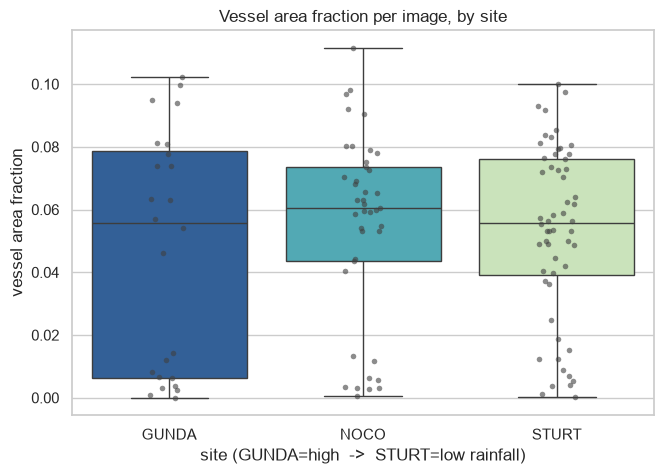

site
GUNDA    0.0556
NOCO     0.0605
STURT    0.0559
Name: vessel_fraction, dtype: float64

In [11]:
area_fraction = pd.read_csv("outputs/area_fraction.csv")

fig, ax = plt.subplots(figsize=(7.5, 5))
sns.boxplot(data=area_fraction, x="site", y="vessel_fraction", order=SITE_ORDER,
            hue="site", hue_order=SITE_ORDER, palette="YlGnBu_r", legend=False,
            showfliers=False, ax=ax)
sns.stripplot(data=area_fraction, x="site", y="vessel_fraction", order=SITE_ORDER,
              color="0.25", size=4, alpha=0.6, ax=ax)
ax.set_xlabel("site (GUNDA=high  ->  STURT=low rainfall)")
ax.set_ylabel("vessel area fraction")
ax.set_title("Vessel area fraction per image, by site")
plt.show()

area_fraction.groupby("site")["vessel_fraction"].median().reindex(SITE_ORDER).round(4)

## Takeaways

- Vessel **size**, **roundness**, and **elongation** are now measured with the
  corrected pipeline — circularity in particular reflects the unbiased Crofton
  perimeter, so it is comparable to values in the literature.
- The box plots and summary table show how each metric shifts (or doesn't) from
  high- to low-rainfall sites.
- The area-fraction plot summarises vessel packing per section.

To turn the pixel numbers into microns, set `CALIBRATION_UM_PER_PX["10x"]` in
`config.py`, re-run notebook 2, and re-run this one — the figures regenerate in
real-world units.